# Packages

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split,cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

C:\Users\mduro\AppData\Local\Temp\ipykernel_8232\450083491.py:1: DtypeWarning: Columns (46,48,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/processed_data_pre_model.csv")


# Feature Engineering

In [3]:
df.head(1)

,month_date_yyyymm,county_fips,county_name_x,median_listing_price_x,median_listing_price_mm_x,median_listing_price_yy_x,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market_x,...,U.S. 30 year FRM,30 year fees & points,U.S. 15 year FRM,15 year fees & points,U.S. 5/1 ARM,5/1 year fees & points,U.S. 5/1 ARM margin,30 year FRM / 5/1 ARM spread,date_y,highest_category
0,2016-07-01,1001,"autauga, al",186400.0,NaN,NaN,295,NaN,NaN,72.0,...,3.44,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69,NaN,NaN


In [4]:
# Cleaning columns

# Dropping lags, dupicate columns
df = df[['month_date_yyyymm'
                      , 'county_fips'
                      , 'county_name_x'
                      , 'median_listing_price_x' #taking median to control for outliers
                      , 'active_listing_count'
                      , 'median_days_on_market_x'
                      , 'new_listing_count'
                      , 'price_increased_count'
                      , 'price_increased_share'
                      , 'price_reduced_count'
                      , 'price_reduced_share'
                      , 'pending_listing_count'
                      #, 'median_listing_price_per_square_foot' #leaking target
                      , 'median_square_feet'
                      #, 'average_listing_price' #leaking target
                      , 'total_listing_count'
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

In [5]:
df['30 year fees & points'].unique()

array([0.5  , 0.525, 0.54 , 0.55 , 0.475, 0.48 , 0.44 , 0.45 , 0.46 ,
       0.56 , 0.65 , 0.72 , 0.7  , 0.725, 0.8  , 0.78 , 0.675, 0.66 ,
       0.68 , 0.9  , 0.86 , 0.775, 0.82 , 0.825, 0.85 ,   nan])

# Feature analysis

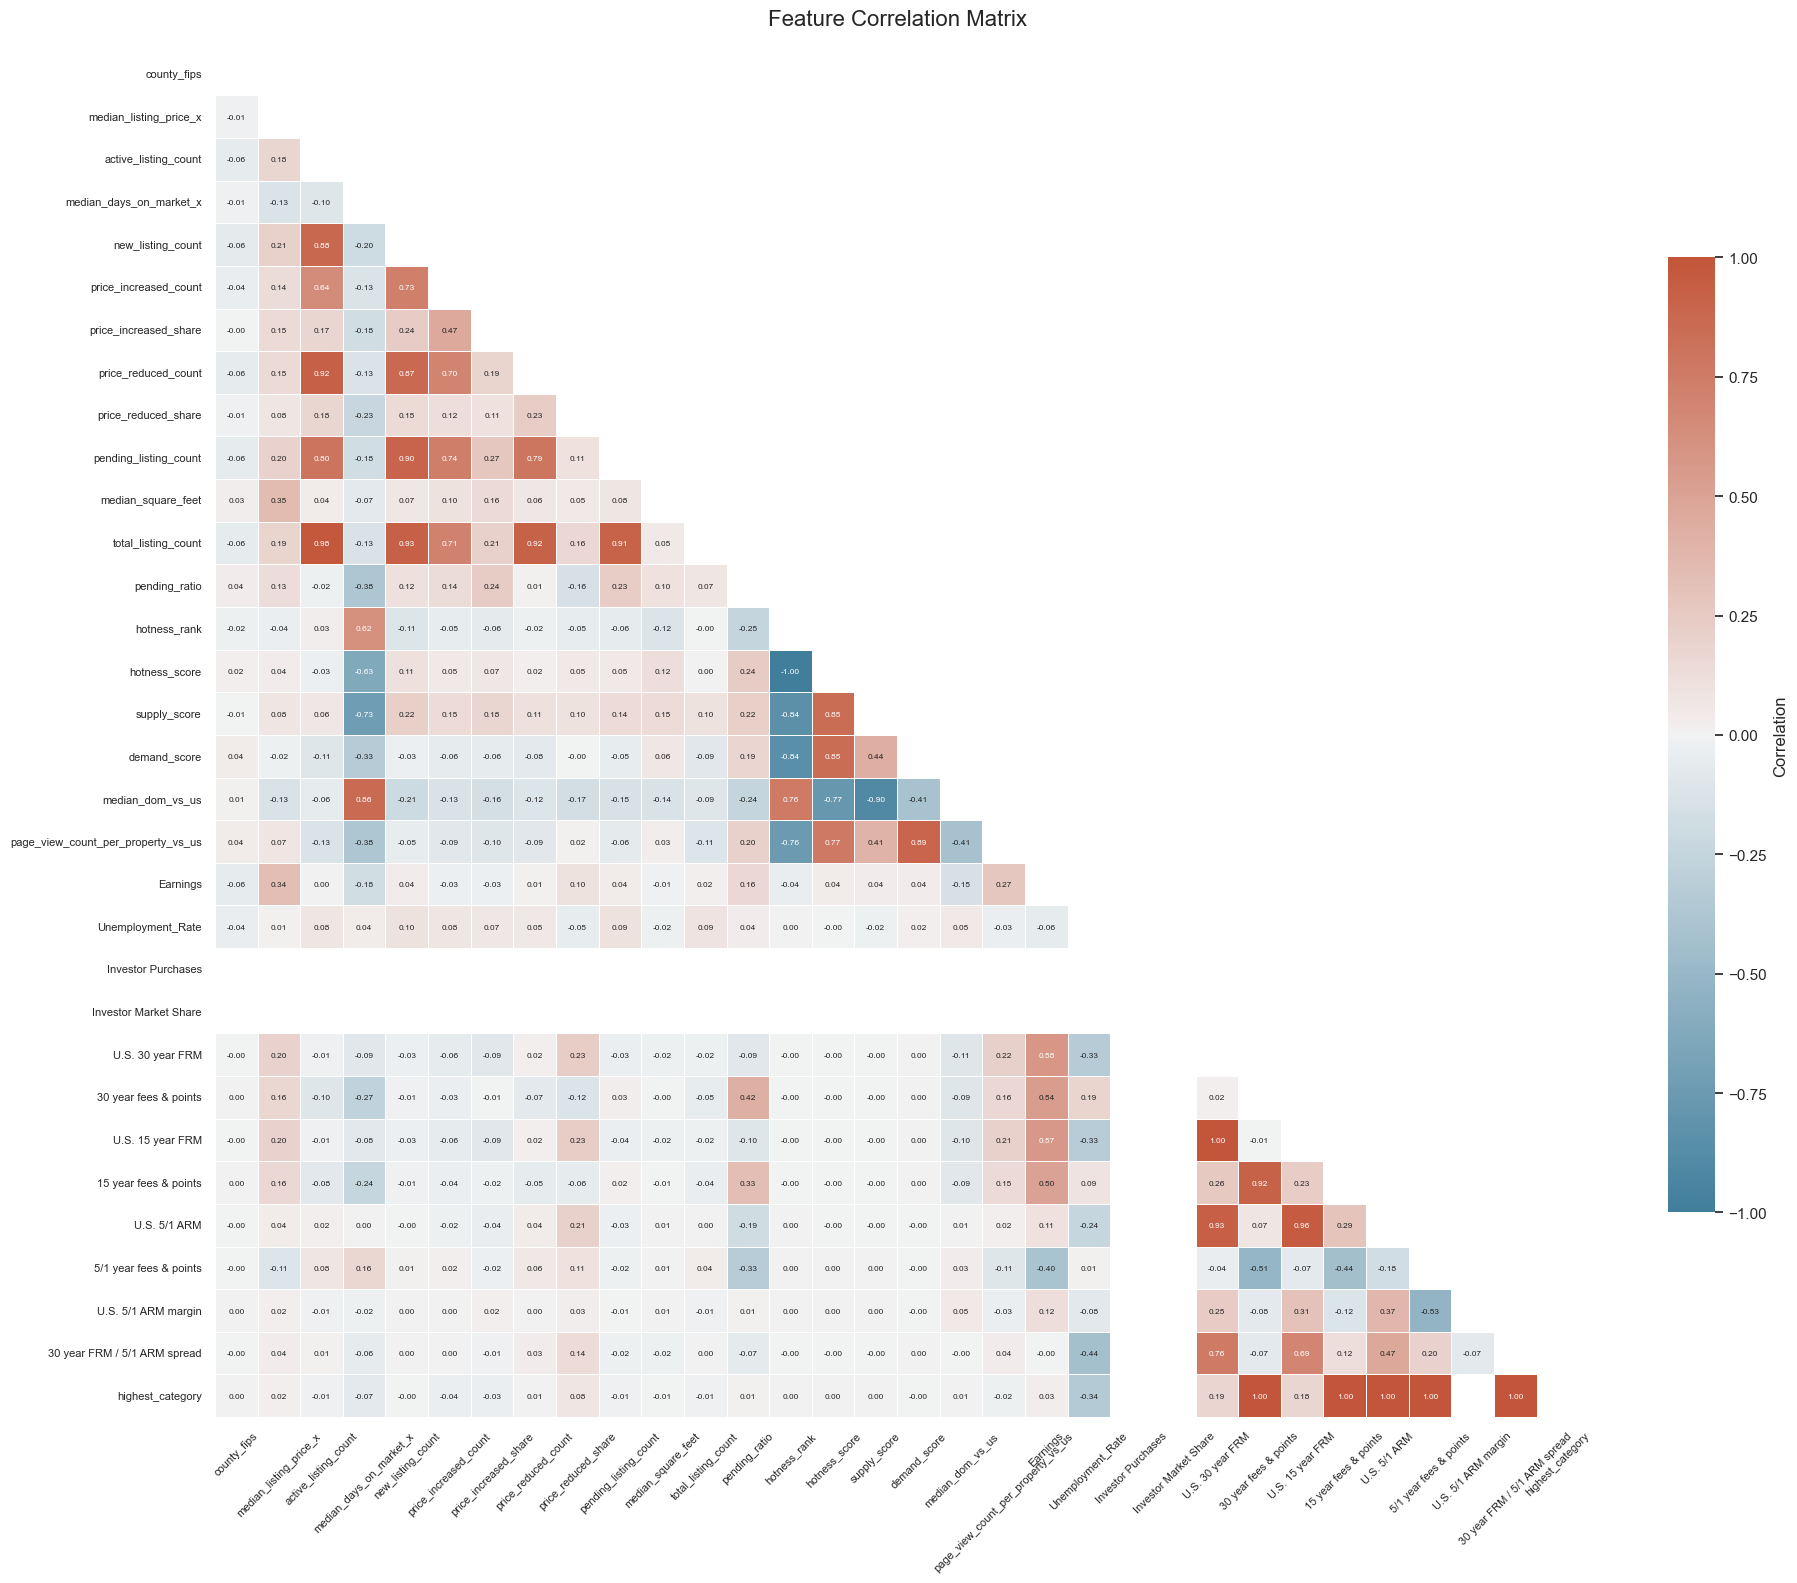

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.select_dtypes(include=[np.number]).corr()

# Cluster the correlation matrix for better grouping
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(20, 16))

# Mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlation"},
    ax=ax
)

ax.set_title("Feature Correlation Matrix", fontsize=16, pad=20)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

- Total listing count and total price reduced are highly correlated with median list price.
- Morgage data seem off, some have correlation of 1 for features un related like highest category.
- Some multi coleanarity. Hotness score and hotness rank.

In [7]:
df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
                 ,'highest_category' #Florida only, dropping for now
                 ], inplace=True)

In [8]:
df[df['Investor Market Share'].isna()]

,month_date_yyyymm,county_fips,county_name_x,median_listing_price_x,active_listing_count,median_days_on_market_x,new_listing_count,price_increased_count,price_increased_share,price_reduced_count,...,Investor Purchases,Investor Market Share,U.S. 30 year FRM,30 year fees & points,U.S. 15 year FRM,15 year fees & points,U.S. 5/1 ARM,5/1 year fees & points,U.S. 5/1 ARM margin,30 year FRM / 5/1 ARM spread
0,2016-07-01,1001,"autauga, al",186400.0,295,72.0,100,0,0.0000,56.0,...,NaN,NaN,3.4400,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69
1,2016-07-01,1003,"baldwin, al",309900.0,2924,83.0,680,64,0.0178,520.0,...,NaN,NaN,3.4400,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69
2,2016-07-01,1005,"barbour, al",187000.0,143,127.0,16,0,0.0000,8.0,...,NaN,NaN,3.4400,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69
3,2016-07-01,1007,"bibb, al",161000.0,71,80.0,20,0,0.0000,12.0,...,NaN,NaN,3.4400,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69
4,2016-07-01,1009,"blount, al",149900.0,273,79.0,72,4,0.0105,64.0,...,NaN,NaN,3.4400,0.5,2.7475,0.475,2.75,0.475,2.7425,0.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360048,2026-02-01,56037,"sweetwater, wy",339000.0,108,52.0,44,0,0.0000,36.0,...,NaN,NaN,6.0475,NaN,5.4325,NaN,NaN,NaN,NaN,NaN
360049,2026-02-01,56039,"teton, wy",3210000.0,187,149.0,38,0,0.0000,12.0,...,NaN,NaN,6.0475,NaN,5.4325,NaN,NaN,NaN,NaN,NaN
360050,2026-02-01,56041,"uinta, wy",432500.0,60,89.0,20,0,0.0000,8.0,...,NaN,NaN,6.0475,NaN,5.4325,NaN,NaN,NaN,NaN,NaN
360051,2026-02-01,56043,"washakie, wy",297500.0,23,57.0,6,0,0.0000,6.0,...,NaN,NaN,6.0475,NaN,5.4325,NaN,NaN,NaN,NaN,NaN


# XGB

### Define target + features

In [9]:
## Takes about ~32 seconds on GPU

# ---------------------------
# 1. Define target + features
# ---------------------------
target_col = "median_listing_price_x"  # change if needed

df["price_lag_1"] = df.groupby("county_fips")["median_listing_price_x"].shift(1)
df["price_roll_3"] = df.groupby("county_fips")["median_listing_price_x"].shift(1).rolling(3).mean()
# Drop non-numeric columns (RF can’t handle strings directly)
# Drop rows where target is NaN
df_clean = df.dropna(subset=["median_listing_price_x"])

X = df_clean.drop(columns=["median_listing_price_x"])
y = df_clean["median_listing_price_x"]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

### Train/Test Split

In [10]:
# ---------------------------
# 2. Train/Test Split
# ---------------------------

####Learn this more
f = df.sort_values("month_date_yyyymm")

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

### Pipeline

In [11]:
# ---------------------------
# 3. Pipeline
# ---------------------------
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    
    # Remove low-variance features
    ("variance", VarianceThreshold(threshold=0.01)),
    
    # Optional for RF/XGB?(confirm), but keeps things consistent
    ("scaler", StandardScaler()),
    
    ("model", XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    device="cuda",  # GPU enabled
    random_state=42
))
])

# ---------------------------
# 4. Train
# ---------------------------
pipeline.fit(X_train, y_train)

# ---------------------------
# 5. Predict + Evaluate
# ---------------------------
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

# Get mask of selected features
    #variance_mask = pipeline.named_steps["variance"].get_support()

#selected_features = X.columns[variance_mask]
    #print("Selected Features:")
    #print(selected_features)

c:\Users\mduro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Investor Purchases' 'Investor Market Share']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


RMSE: 79775.87
R²: 0.8872


c:\Users\mduro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Investor Purchases' 'Investor Market Share']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\mduro\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [20:04:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


### Cross Validation

In [ ]:
# Define CV strategy
from sklearn.model_selection import TimeSeriesSplit

kf = TimeSeriesSplit(n_splits=5)

# RMSE (negative because sklearn maximizes scores)
rmse_scores = cross_val_score(
    pipeline,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

# R² scores
r2_scores = cross_val_score(
    pipeline,
    X,
    y,
    scoring="r2",
    cv=kf,
    n_jobs=-1
)

# Convert RMSE back to positive
rmse_scores = -rmse_scores

print("Cross-Validation Results:")
print(f"RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"R²: {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# Pytorch

#### Packages

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV

#### Prepare the data

In [ ]:
error_score='raise'

class TorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, input_dim=None, lr=0.0003, epochs=50, batch_size=1024):
        self.input_dim = input_dim
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def _build_model(self):
        return nn.Sequential(
            nn.Linear(self.input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(self.device)

    def fit(self, X, y):
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32).reshape(-1, 1)

        self.input_dim = X.shape[1]
        self.model = self._build_model()

        X_tensor = torch.tensor(X).to(self.device)
        y_tensor = torch.tensor(y).to(self.device)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        for epoch in range(self.epochs):
            self.model.train()
            perm = torch.randperm(X_tensor.size(0))

            for i in range(0, X_tensor.size(0), self.batch_size):
                idx = perm[i:i+self.batch_size]
                batch_X = X_tensor[idx]
                batch_y = y_tensor[idx]

                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)

                # NaN guard
                if torch.isnan(loss):
                    raise ValueError("Loss became NaN")

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

        return self

    def predict(self, X):
        self.model.eval()
        X = np.array(X, dtype=np.float32)
        X_tensor = torch.tensor(X).to(self.device)

        with torch.no_grad():
            preds = self.model(X_tensor).cpu().numpy()

        return preds.flatten()

#### Pipeline

In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("model", TorchRegressor(
        lr=0.0003,
        epochs=50,
        batch_size=1024
        #epochs=30, input_dim=37 # Grid-searched values
    ))
])

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

y = np.log1p(y)

#### Move to GPU (if available)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Handle both pandas DataFrames and torch Tensors (in case cell is re-run)
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().numpy()
    elif hasattr(x, 'values'):
        return x.values.astype(np.float32)
    return np.array(x, dtype=np.float32)

# Clean data → numpy (for sklearn pipeline)
X_train_np = np.nan_to_num(to_numpy(X_train), nan=0.0, posinf=0.0, neginf=0.0)
X_test_np = np.nan_to_num(to_numpy(X_test), nan=0.0, posinf=0.0, neginf=0.0)
y_train_np = np.nan_to_num(np.log1p(to_numpy(y_train).ravel()), nan=0.0, posinf=0.0, neginf=0.0)
y_test_np = np.nan_to_num(np.log1p(to_numpy(y_test).ravel()), nan=0.0, posinf=0.0, neginf=0.0)

# GPU tensors (for standalone PyTorch model)
X_train_t = torch.tensor(X_train_np).to(device)
y_train_t = torch.tensor(y_train_np).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test_np).to(device)
y_test_t = torch.tensor(y_test_np).unsqueeze(1).to(device)

#### Grid Search

#### Training and evaluation

In [ ]:
pipeline.fit(X_train_np, y_train_np)
y_pred = pipeline.predict(X_test_np)

# Inverse log1p transform to get original scale
y_test_orig = np.expm1(y_test_np)
y_pred_orig = np.expm1(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

RMSE: 115335.98
R²:   0.7643


#### Testing

In [ ]:
# Check for NaNs / inf
print(np.isnan(X_train_np).sum())
print(np.isinf(X_train_np).sum())

0
0
